In [ ]:
# Python Project: NYC Public Schools Regents Exam Analysis
# Objective: Identify the most difficult Regents exams based on Mean Score
# and analyze how Newtown High School performs compared to NYC averages.

In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.2100999999046325 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                    

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [4]:
# Preview dataset structure
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [5]:
# Inspect Data
# Check data types and missing values
df.info()

# Check missing values per column
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   School DBN                   212331 non-null  str  
 1   School Name                  212331 non-null  str  
 2   School Level                 212331 non-null  str  
 3   Regents Exam                 212321 non-null  str  
 4   Year                         212331 non-null  int64
 5   Total Tested                 212331 non-null  int64
 6   Mean Score                   212331 non-null  str  
 7   Number Scoring Below 65      212331 non-null  str  
 8   Percent Scoring Below 65     212331 non-null  str  
 9   Number Scoring 65 or Above   212331 non-null  str  
 10  Percent Scoring 65 or Above  212331 non-null  str  
 11  Number Scoring 80 or Above   212331 non-null  str  
 12  Percent Scoring 80 or Above  212331 non-null  str  
 13  Number Scoring CR            212331 non-

School DBN                      0
School Name                     0
School Level                    0
Regents Exam                   10
Year                            0
Total Tested                    0
Mean Score                      0
Number Scoring Below 65         0
Percent Scoring Below 65        0
Number Scoring 65 or Above      0
Percent Scoring 65 or Above     0
Number Scoring 80 or Above      0
Percent Scoring 80 or Above     0
Number Scoring CR               0
Percent Scoring CR              0
dtype: int64

In [8]:
# Data Cleaning
# Select only relevant columns for analysis
df1 = df[[
    "School DBN",
    "School Name",
    "School Level",
    "Regents Exam",
    "Year",
    "Total Tested",
    "Mean Score"
]].copy()

# Clean text columns (remove extra spaces)
df1["Regents Exam"] = df1["Regents Exam"].str.strip()
df1["School Name"] = df1["School Name"].str.strip()

# Convert numeric columns
for col in ["Mean Score", "Total Tested", "Year"]:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

# Check missing values after conversion
df1.isnull().sum()

# Remove rows with missing key values
df1 = df1.dropna(subset=["Mean Score", "Regents Exam"])

# Remove duplicate rows
df1 = df1.drop_duplicates()

In [9]:
# Descriptive Statistics
# Summary statistics of Mean Score by Regents Exam
df1.groupby("Regents Exam")["Mean Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Regents Exam,,,,,,,,
Algebra2/Trigonometry,5011.0,56.640671,13.385223,19.1,47.4,55.7,64.8,95.2
Common Core Algebra,18936.0,67.283962,9.808720,37.2,60.2,65.9,73.8,96.6
Common Core Algebra2,4109.0,63.693891,9.370709,33.6,57.1,63.5,69.9,90.9
Common Core English,13169.0,70.349184,11.829594,15.0,63.4,71.3,78.3,98.3
Common Core Geometry,9323.0,59.103389,10.103539,27.0,52.0,57.9,65.6,92.1
English,6681.0,65.781679,9.960041,30.7,59.0,66.0,72.1,95.1
Geometry,4174.0,61.913824,10.746104,29.0,54.3,61.3,68.9,95.1
Global History and Geography,14615.0,64.141102,10.631939,28.7,56.8,62.7,70.6,97.0
Integrated Algebra,6177.0,64.750413,6.998432,36.7,60.3,64.4,68.8,95.9


<Axes: title={'center': 'NYC Regents Exam Difficulty (Based on Mean Score)'}, xlabel='Average Mean Score', ylabel='Regents Exam'>

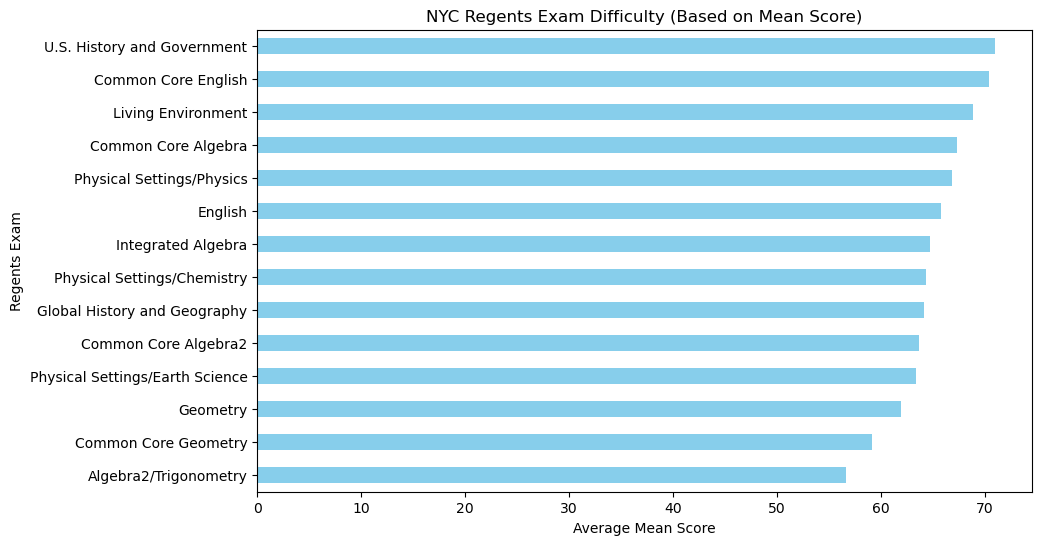

In [12]:
# NYC Exam Difficulty (Lower Score = More Difficult)
# Compute average Mean Score per Regents Exam across NYC
nyc_exam_avg = df1.groupby("Regents Exam")["Mean Score"].mean().sort_values()

# Visualize exam difficulty
nyc_exam_avg.plot(
    kind="barh",
    figsize=(10, 6),
    color="skyblue",
    title="NYC Regents Exam Difficulty (Based on Mean Score)",
    xlabel="Average Mean Score",
    ylabel="Regents Exam"
)

<Axes: title={'center': 'Newtown High School Regents Performance'}, xlabel='Mean Score', ylabel='Regents Exam'>

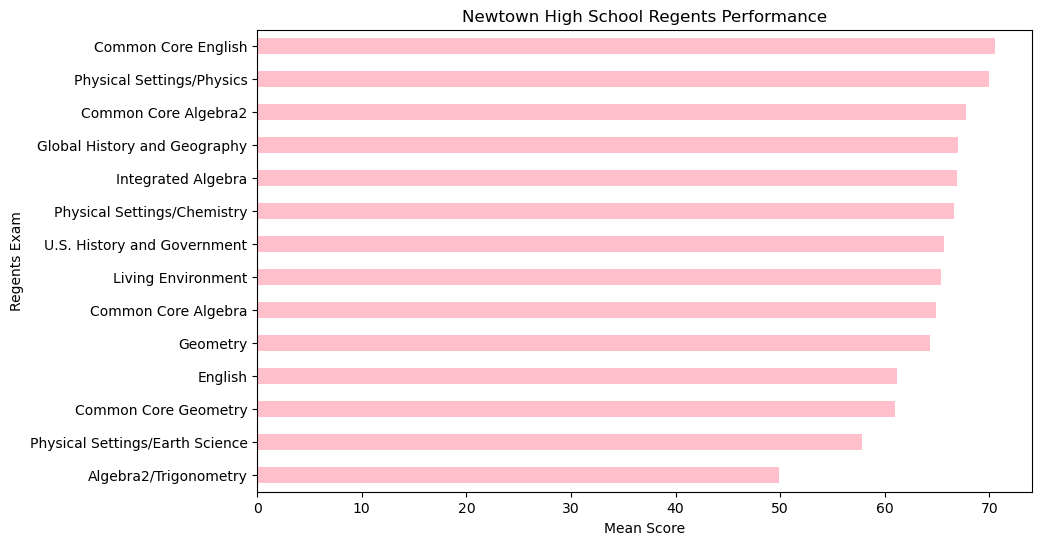

In [13]:
# Newtown High School Performance
# Select school for comparison
school_name = "Newtown High School"
school_df = df1[df1["School Name"] == school_name]

# Compute average score per exam for the school
school_exam_avg = school_df.groupby("Regents Exam")["Mean Score"].mean().sort_values()

# Visualize school performance
school_exam_avg.plot(
    kind="barh",
    figsize=(10, 6),
    color="pink",
    title="Newtown High School Regents Performance",
    xlabel="Mean Score",
    ylabel="Regents Exam"
)

In [14]:
# NYC vs School Comparison
# Combine NYC and school averages into one table
comparison = pd.DataFrame({
    "NYC Average": nyc_exam_avg,
    "School Average": school_exam_avg
}).dropna().sort_values(by="NYC Average")

comparison

,NYC Average,School Average
Regents Exam,,
Algebra2/Trigonometry,56.640671,49.911765
Common Core Geometry,59.103389,60.924138
Geometry,61.913824,64.281818
Physical Settings/Earth Science,63.376070,57.845455
Common Core Algebra2,63.693891,67.771429
Global History and Geography,64.141102,67.037838
Physical Settings/Chemistry,64.290944,66.590000
Integrated Algebra,64.750413,66.929167
English,65.781679,61.122727


<Axes: title={'center': 'Newtown High School vs NYC Regents Performance'}, xlabel='Mean Score', ylabel='Regents Exam'>

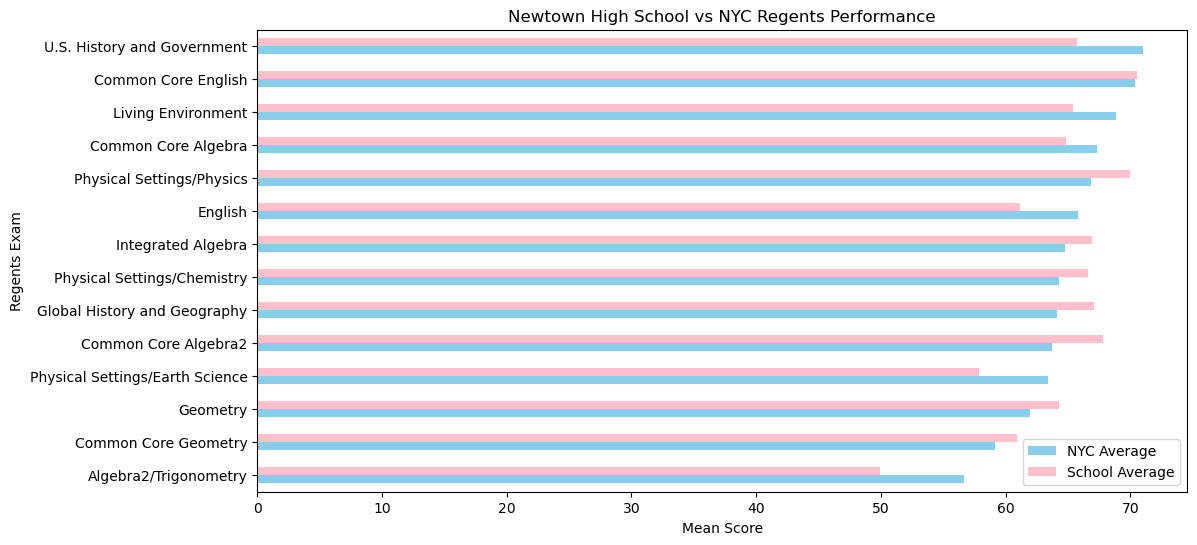

In [16]:
# Comparison Visualization
# Visual comparison between NYC and Newtown High School
comparison.plot(
    kind="barh",
    figsize=(12, 6),
    title="Newtown High School vs NYC Regents Performance",
    xlabel="Mean Score",
    ylabel="Regents Exam",
    color=["skyblue", "pink"]
)


In [ ]:
# Final conclusion of analysis

"""
The analysis shows that Algebra 2/Trigonometry has the lowest average mean score across NYC, suggesting it is one of the most challenging Regents exams. Newtown High School also performs weakest on this exam, with scores below the NYC average. This indicates that students at Newtown High School face similar difficulties as students across the city.
"""